In [1]:
import sys
import os
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from starcat import BuildConsensusReference, starCAT

/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/minicon

In [2]:
adata = sc.read_h5ad("/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/5.startCAT-SLE/GSE135779_PBMC_SLE_Adult_celltype_harmony_umap.h5ad")
# 2. 只保留 NK 细胞

query_adata = adata[adata.obs['celltype'] == 'NK'].copy()
query_adata

AnnData object with n_obs × n_vars = 4714 × 21024
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'join_key', 'index', 'IDs', 'Names', 'SLEDAI', 'subclusters', 'clean_seq', 'sample', 'group', 'age_group', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype', 'barcode'
    obsm: 'X_harmony', 'X_pca', 'X_umap'

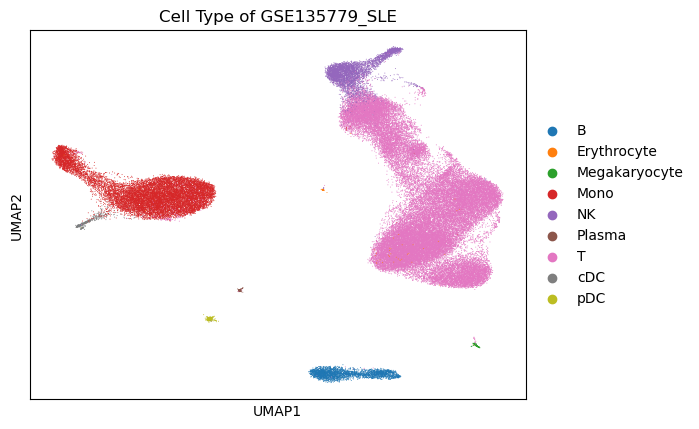

In [3]:
sc.pl.umap(adata, color='celltype', title='Cell Type of GSE135779_SLE')

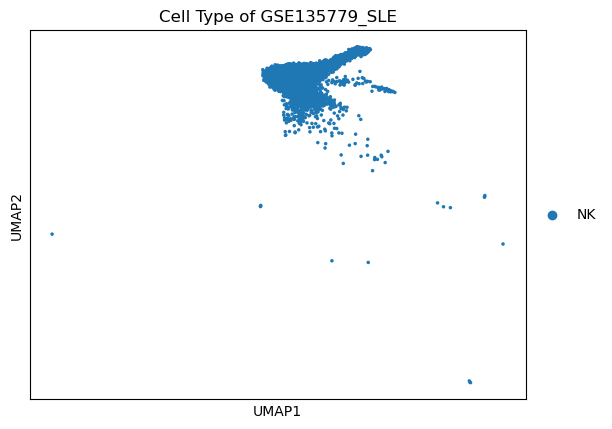

In [4]:
sc.pl.umap(query_adata, color='celltype', title='Cell Type of GSE135779_SLE')

In [5]:
#group: healthy controls (HD) \  SLE
query_adata.obs['group'].value_counts()

HD     2977
SLE    1737
Name: group, dtype: int64

In [6]:
custom_tcat = starCAT(reference='/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.3.cNMF_NK/Example_refbuilder_NK/starcat_refstarcat_consensus_spectra_normalized.filtered.txt')

usage, _ = custom_tcat.fit_transform(query_adata)


Using user specified reference spectra file /sibcb1/bioinformatics/yangyue/project/immunotherapy/7.3.cNMF_NK/Example_refbuilder_NK/starcat_refstarcat_consensus_spectra_normalized.filtered.txt
No scores provided
5311 out of 5311 genes in the reference overlap with the query


In [7]:
usage

,cGEP1,cGEP2,cGEP3,cGEP4,cGEP5,cGEP6,cGEP7,cGEP8,cGEP9,cGEP10,...,cGEP32,cGEP33,cGEP34,cGEP35,cGEP36,cGEP37,cGEP38,cGEP39,cGEP40,cGEP41
GSM4029940_JB19001_AAAGTAGAGTCATGCT-1,0.051553,0.000980,0.000034,0.017071,0.064873,0.198380,0.000401,0.003311,0.084695,4.879612e-06,...,0.000247,0.002672,0.002011,0.038345,0.000029,0.000220,0.029206,0.003532,0.008599,0.000489
GSM4029940_JB19001_AAAGTAGCAGCTGCAC-1,0.081308,0.173275,0.004536,0.011432,0.004527,0.042639,0.002191,0.008846,0.003119,2.535550e-03,...,0.004657,0.000536,0.015043,0.060166,0.001934,0.041354,0.014683,0.039941,0.064109,0.008088
GSM4029940_JB19001_AAAGTAGTCTCTGAGA-1,0.017155,0.000320,0.000592,0.069994,0.000039,0.014246,0.021234,0.005751,0.019453,1.803557e-06,...,0.000232,0.013201,0.000065,0.009498,0.000004,0.001065,0.010787,0.100584,0.299417,0.000061
GSM4029940_JB19001_AACACGTTCCTATTCA-1,0.107519,0.004585,0.000518,0.028601,0.005667,0.108326,0.002694,0.024635,0.075210,2.418709e-04,...,0.004640,0.013414,0.003969,0.003202,0.004364,0.004076,0.027123,0.001613,0.000982,0.000300
GSM4029940_JB19001_AACCATGCAGCCACCA-1,0.118683,0.078694,0.003987,0.008633,0.025533,0.300575,0.000825,0.000308,0.008501,1.982241e-03,...,0.000404,0.004794,0.001018,0.065338,0.007638,0.000726,0.039214,0.011602,0.000077,0.009068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM4029952_JB19015_TTGAACGAGATGGCGT-1,0.063081,0.177973,0.134433,0.066047,0.002330,0.008025,0.032363,0.006466,0.006995,1.514154e-05,...,0.002658,0.025510,0.000387,0.051901,0.000043,0.001529,0.008075,0.043725,0.000456,0.018296
GSM4029952_JB19015_TTGAACGTCACCGGGT-1,0.042466,0.584012,0.020448,0.001010,0.009711,0.011424,0.000175,0.000409,0.000463,2.808162e-03,...,0.000429,0.000568,0.007693,0.032111,0.016369,0.003973,0.004064,0.006267,0.000642,0.003656
GSM4029952_JB19015_TTGACTTCAGGAATCG-1,0.103134,0.316917,0.002529,0.003600,0.020321,0.010284,0.040028,0.001017,0.001692,2.775051e-03,...,0.005327,0.000866,0.001673,0.132254,0.013089,0.002692,0.004664,0.055404,0.000339,0.005700
GSM4029952_JB19015_TTTGCGCGTCTCTCTG-1,0.060203,0.055126,0.003160,0.062014,0.005903,0.009904,0.019894,0.047048,0.013161,2.582560e-07,...,0.001049,0.008674,0.000646,0.045926,0.000019,0.000969,0.029814,0.027541,0.000091,0.002031


In [8]:
usage.to_csv("/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.3.cNMF_NK/5.disease/5.2.SLE/5.2.NK_SLE_GSE135779_cGEP_usage_cell_level.csv")


In [9]:
# 加上cGEP对应的注释
gep_anno = pd.read_csv("/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.3.cNMF_NK/3.3.NK_cGEP_ALL_ANNO/3.3.NK_cGEP_Anno_Complete_With_Genes_final.csv")
# 去掉 Class 为 Artifact 或 Doublet  的行
gep_anno_filt = gep_anno[~gep_anno["Category"].isin(["Artifact", "Doublet"])]
gep_anno_filt

# 1. 找出 Artifact / Doublet  对应的 cGEP 名称
remove_geps = (
    gep_anno.loc[
        gep_anno["Category"].isin(["Artifact", "Doublet"]),
        "cGEP_Cluster"]
    .unique()
    .tolist()
)

print("需要去掉的 cGEP：", remove_geps)

# 2. 从 usage 表格中去掉这些 cGEP 列
usage = usage.drop(columns=remove_geps, errors="ignore")

usage.head()

# 1. 修正字典构建逻辑
# 去掉代码中的 "cGEP" 前缀，直接读取
anno_dict = {
    row['cGEP_Cluster']: f"{row['cGEP_Cluster']}_{row['cGEP_Anno_Name']}" 
    for index, row in gep_anno_filt.iterrows()
}

# 2. 再次检查映射字典
# 正确的样子应该是: [('cGEP1', 'cGEP1_Translation'), ...]
print("修正后的映射字典 (前3个):")
print(list(anno_dict.items())[:3])

# 3. 执行重命名
usage.rename(columns=anno_dict, inplace=True)

# 4. 验证结果
print("新的列名:")
print(usage.columns[:5])

需要去掉的 cGEP： ['cGEP1', 'cGEP11', 'cGEP12', 'cGEP13', 'cGEP16', 'cGEP17', 'cGEP18', 'cGEP19', 'cGEP20', 'cGEP21', 'cGEP24', 'cGEP25', 'cGEP26', 'cGEP32', 'cGEP33', 'cGEP36', 'cGEP37', 'cGEP38', 'cGEP41']
修正后的映射字典 (前3个):
[('cGEP2', 'cGEP2_TaNK_Cytoskeleton_Stress'), ('cGEP3', 'cGEP3_Translational_Activity'), ('cGEP4', 'cGEP4_TaNK_HSP_Stress')]
新的列名:
Index(['cGEP2_TaNK_Cytoskeleton_Stress', 'cGEP3_Translational_Activity',
       'cGEP4_TaNK_HSP_Stress', 'cGEP5_NK_Activation_IEG',
       'cGEP6_Acute_Inflammatory'],
      dtype='object')


In [10]:
# ===========================
# 步骤 1: 准备数据到 obs 中
# ===========================
print("正在将 Usage 数据同步到 adata.obs...")

# 获取 usage 表格中所有的列名（即所有的 GEP 名字）
all_gep_names = usage.columns.tolist()

# 将这些数据赋值给 query_adata.obs
# 我们加一个统一的前缀 "Usage: "，这样在图的标题里看起来更清晰
plot_features_list = []
for col in all_gep_names:
    # 新名字例如："Usage: cGEP1_Translation"
    new_obs_name = f"Usage: {col}"
    query_adata.obs[new_obs_name] = usage[col].values
    plot_features_list.append(new_obs_name)

n_geps = len(plot_features_list)
print(f"准备就绪，共计 {n_geps} 个 GEP 将被绘制。")

正在将 Usage 数据同步到 adata.obs...
准备就绪，共计 22 个 GEP 将被绘制。


开始绘制 UMAP，这可能需要一点时间...


/var/tmp/ipykernel_20038/2819245596.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()



>>> 绘图完成！ <<<


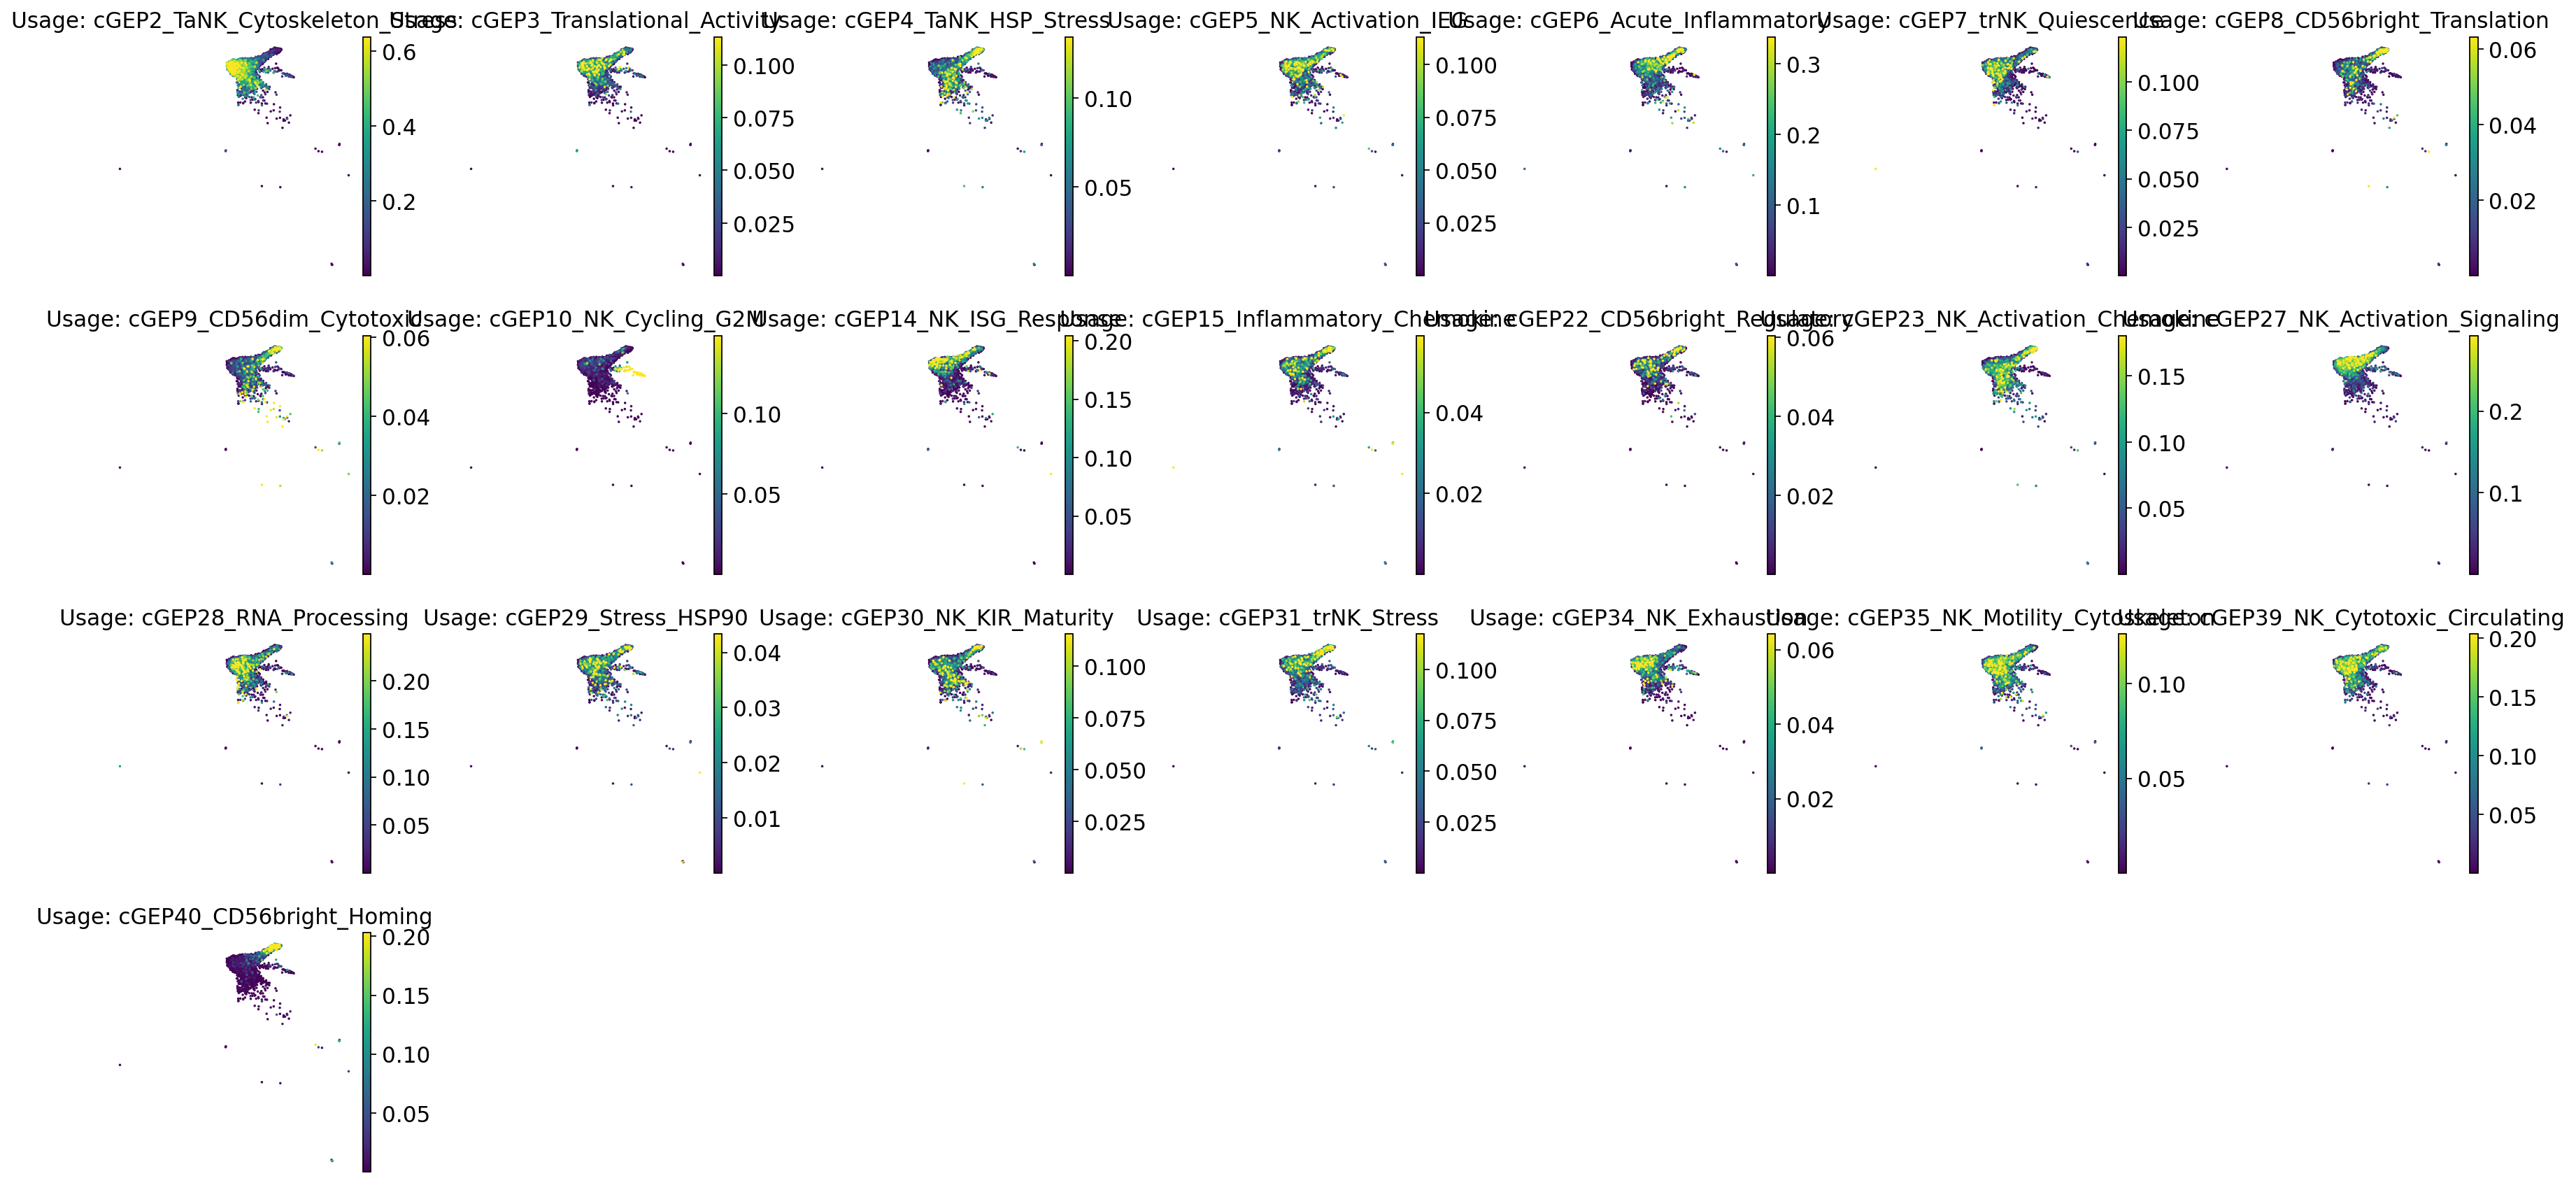

In [11]:
# ===========================
# 步骤 2: 批量绘图并保存
# ===========================
print("开始绘制 UMAP，这可能需要一点时间...")

# 设置绘图参数
sc.set_figure_params(dpi_save=300, figsize=(3, 3)) # 设置每一张小图的尺寸和保存分辨率

plot = sc.pl.umap(
    query_adata,
    color=plot_features_list, # 传入包含所有名字的列表
    vmax='p99',        # 关键：切除前1%的极端值，否则图可能一片黑
    cmap='viridis',    # 配色方案：viridis(黄紫), plasma(黄蓝), Reds(红)
    ncols=7,           # 每行显示 7 张图 (根据总数调整，70个正好画10行)
    s=10,              # 点的大小
    frameon=False,     # 去掉外边框，更美观
    show=False,        # 关键：设置为 False，不直接在屏幕显示
    return_fig=True    # 返回图像对象以便保存
)
plot.show()
# 定义保存路径
output_filename = "5.disease/5.2.SLE/5.2.NK_SLE_GEP_Usage_Visualization.png"

# 保存图片
# bbox_inches='tight' 可以去除多余白边
plot.savefig(output_filename, bbox_inches='tight')

print(f"\n>>> 绘图完成！ <<<")


# 热图

图片已保存为: ./5.disease/5.2.SLE/5.2.SLE_Usage_group_Heatmap.png


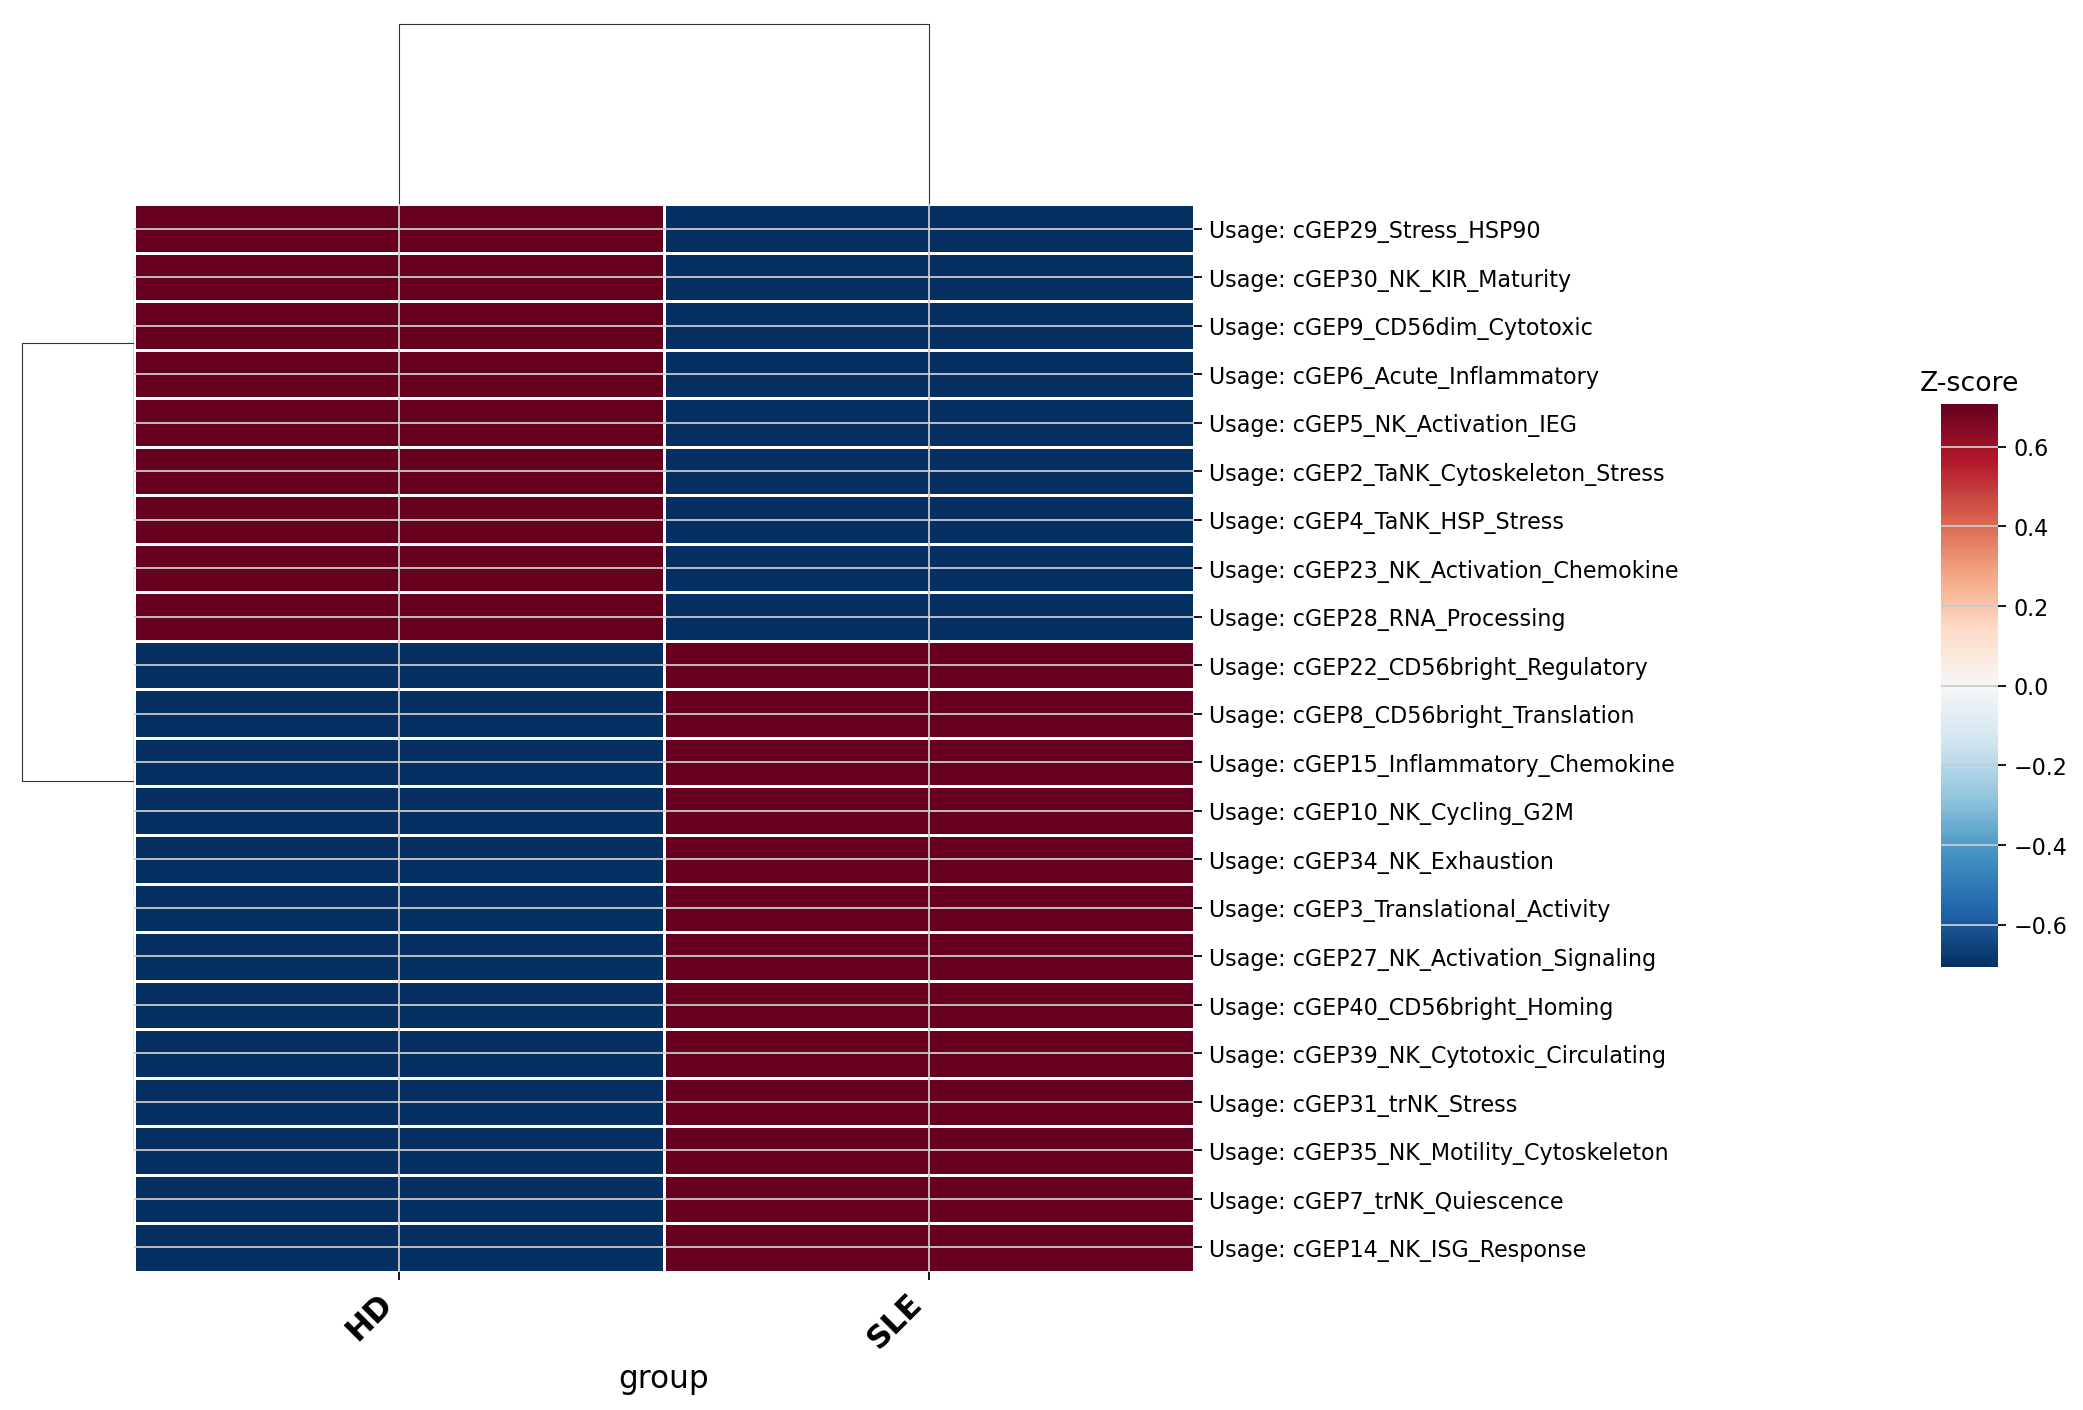

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 筛选数据 (保持不变)
usage_features = [col for col in query_adata.obs.columns if col.startswith('Usage:')]
df = query_adata.obs[usage_features + ['group']]
mean_usage = df.groupby('group').mean()

# 2. 绘制热图
g = sns.clustermap(
    mean_usage.T,
    z_score=0,
    cmap='RdBu_r',
    center=0,
    
    # 画布大小
    figsize=(12, len(usage_features) * 0.4),
    cbar_pos=(1.02, 0.3, 0.03, 0.4), 
    dendrogram_ratio=(0.1, 0.15),
    linewidths=0.5,
    linecolor='white',
    xticklabels=True,
    yticklabels=True
)

# 3. 调整字体和样式
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=14, fontweight='bold', rotation=45, ha='right')
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=10)

# 4. 优化右侧图例的标签
g.ax_cbar.set_title('Z-score', fontsize=12) # 给图例加标题
g.ax_cbar.tick_params(labelsize=10)         # 调整图例刻度字号

# 5. 保存 (bbox_inches='tight' 至关重要，否则右边的图例会被切掉)
output_filename = "./5.disease/5.2.SLE/5.2.SLE_Usage_group_Heatmap.png"
g.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"图片已保存为: {output_filename}")

plt.show()

In [13]:
# 火山图

In [14]:
# 1. 定义映射关系
# 这里的逻辑是：HC -> Healthy, S和M -> COVID
mapping = {
    'HD': 'Healthy',
    'SLE':  'SLE'
}

# 2. 创建新列 'condition'
# 使用 map 函数自动转换
query_adata.obs['group2_condition'] = query_adata.obs['group'].map(mapping)

# 3. 检查一下结果
print("分组统计:")
print(query_adata.obs['group2_condition'].value_counts())

# 检查前几行，确保没填错
print("\n数据预览:")
print(query_adata.obs[['group', 'group2_condition']].head())

分组统计:
Healthy    2977
SLE        1737
Name: group2_condition, dtype: int64

数据预览:
                                      group group2_condition
GSM4029940_JB19001_AAAGTAGAGTCATGCT-1    HD          Healthy
GSM4029940_JB19001_AAAGTAGCAGCTGCAC-1    HD          Healthy
GSM4029940_JB19001_AAAGTAGTCTCTGAGA-1    HD          Healthy
GSM4029940_JB19001_AACACGTTCCTATTCA-1    HD          Healthy
GSM4029940_JB19001_AACCATGCAGCCACCA-1    HD          Healthy


In [15]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 准备数据 ---
# 提取以 "Usage:" 开头的 GEP 列
usage_cols = [c for c in query_adata.obs.columns if c.startswith('Usage:')]
gep_data = query_adata.obs[usage_cols]

# 创建临时 AnnData 对象 (必须步骤，因为 scanpy 的统计工具只认 .X)
gep_adata = sc.AnnData(X=gep_data.values, obs=query_adata.obs)
gep_adata.var_names = usage_cols

# --- 2. 运行统计检验 ---
print("正在对比: SLE (All) vs Healthy...")

sc.tl.rank_genes_groups(
    gep_adata, 
    groupby='group2_condition',  # 【关键】使用您刚创建的新列
    groups=['SLE'],            # 实验组：COVID (包含 M 和 S)
    reference='Healthy',         # 对照组：Healthy (HC)
    method='wilcoxon'            # 秩和检验
)

# 提取结果
result = sc.get.rank_genes_groups_df(gep_adata, group='SLE')
df_volcano = result[['names', 'logfoldchanges', 'pvals_adj']].copy()
df_volcano.columns = ['GEP_Name', 'log2FC', 'padj']

# 清洗数据
df_volcano = df_volcano.replace([np.inf, -np.inf], np.nan).dropna()
print(f"分析完成，前 5 个差异最显著的 GEP:\n{df_volcano.head()}")

正在对比: SLE (All) vs Healthy...
分析完成，前 5 个差异最显著的 GEP:
                                 GEP_Name    log2FC          padj
0           Usage: cGEP14_NK_ISG_Response  2.337273  7.556580e-79
1   Usage: cGEP27_NK_Activation_Signaling  0.378357  2.919868e-30
2  Usage: cGEP39_NK_Cytotoxic_Circulating  0.482583  1.239969e-26
3               Usage: cGEP31_trNK_Stress  0.380783  1.726460e-14
4     Usage: cGEP3_Translational_Activity  0.384698  6.671124e-14


分析完成。前 5 个显著差异 GEP:
                                 GEP_Name    log2FC          padj
0           Usage: cGEP14_NK_ISG_Response  2.337273  7.556580e-79
1   Usage: cGEP27_NK_Activation_Signaling  0.378357  2.919868e-30
2  Usage: cGEP39_NK_Cytotoxic_Circulating  0.482583  1.239969e-26
3               Usage: cGEP31_trNK_Stress  0.380783  1.726460e-14
4     Usage: cGEP3_Translational_Activity  0.384698  6.671124e-14
提示: 未安装 adjustText，标签可能会重叠。建议 pip install adjustText
图片已保存为: ./5.disease/5.2.SLE/5.2.NK_SLE_Volcano_SLETcell_Usage2.png


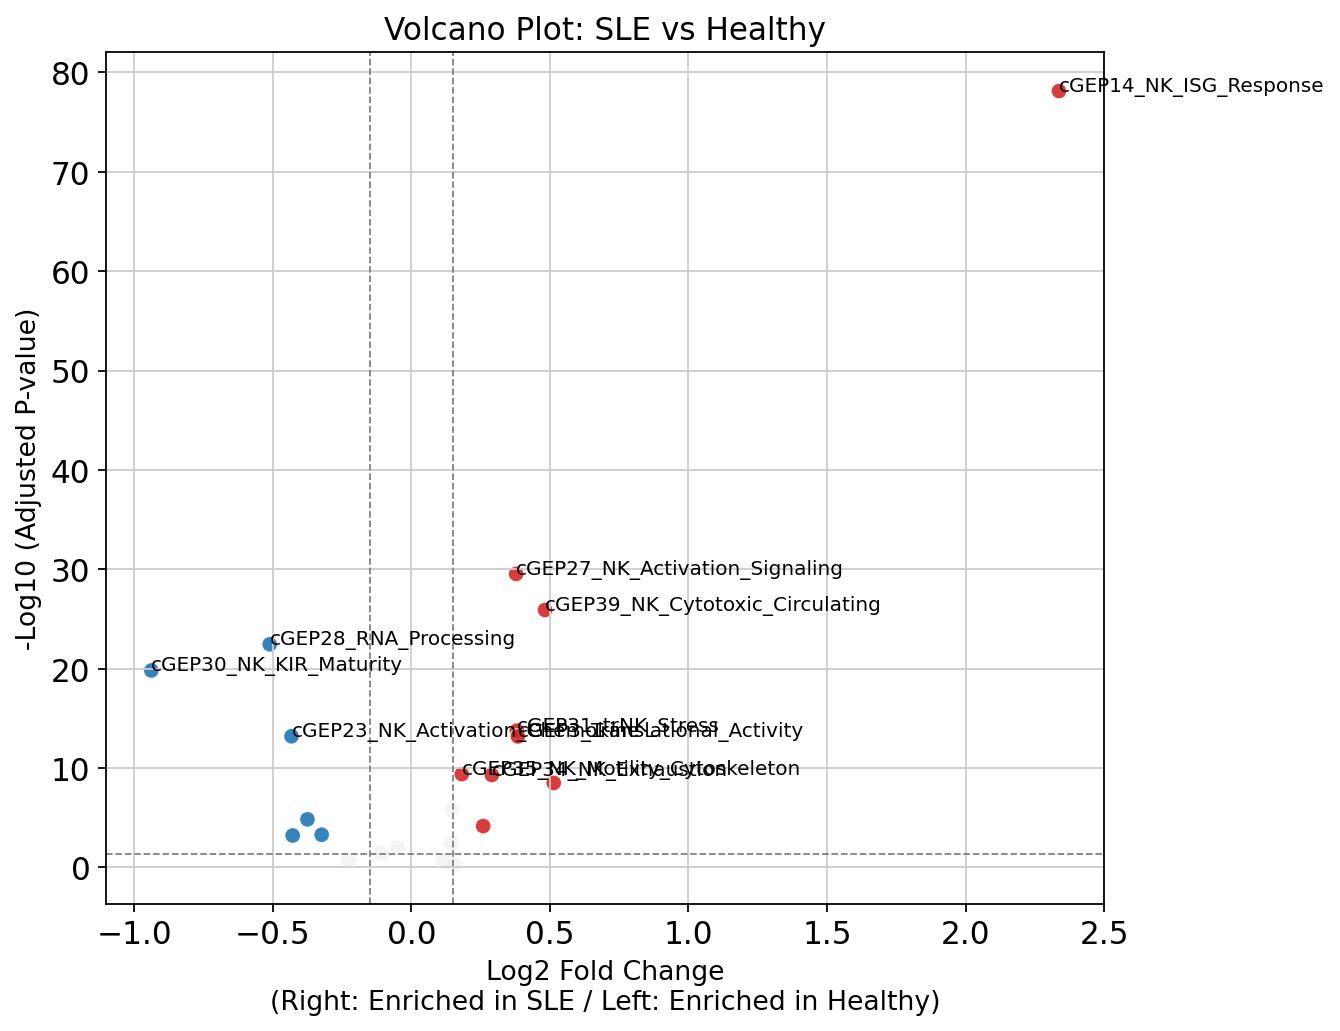

In [16]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from adjustText import adjust_text # 如果没有安装这个库，可以注释掉相关行

# ===========================
# 第一步：准备数据与差异分析
# ===========================

# 1. 提取所有 Usage 列
usage_cols = [c for c in query_adata.obs.columns if c.startswith('Usage:')]
gep_data = query_adata.obs[usage_cols]

# 2. 创建临时 AnnData 对象
# Scanpy 的 rank_genes_groups 只能针对 .X 矩阵计算，所以我们把 Usage 塞进去
gep_adata = sc.AnnData(X=gep_data.values, obs=query_adata.obs)
gep_adata.var_names = usage_cols

# 3. 运行差异分析 (Wilcoxon 秩和检验)

sc.tl.rank_genes_groups(
    gep_adata, 
    groupby='group2_condition',  # 使用您刚才创建的分组
    groups=['SLE'],            # 实验组：
    reference='Healthy',         # 对照组：Healthy
    method='wilcoxon'
)

# 4. 提取结果表
result = sc.get.rank_genes_groups_df(gep_adata, group='SLE')
df_volcano = result[['names', 'logfoldchanges', 'pvals_adj']].copy()
df_volcano.columns = ['GEP_Name', 'log2FC', 'padj']

# 去除无效值
df_volcano = df_volcano.replace([np.inf, -np.inf], np.nan).dropna()
print("分析完成。前 5 个显著差异 GEP:")
print(df_volcano.head())

# ===========================
# 第二步：绘制火山图
# ===========================

# 1. 设置阈值 (Usage 数据是 0-1 的比例，变化幅度不如基因 Counts 大，建议调低 logFC 阈值)
pval_th = 0.05
logfc_th = 0.15  # 意味着 Usage 发生了约 1.1 倍的变化即可

# 2. 定义颜色
df_volcano['color'] = '#dddddd' # 默认灰色
df_volcano['alpha'] = 0.3       # 默认透明度

# 红色：显著上调 (COVID 特征)
up_mask = (df_volcano['padj'] < pval_th) & (df_volcano['log2FC'] > logfc_th)
df_volcano.loc[up_mask, 'color'] = '#D62728' # Red
df_volcano.loc[up_mask, 'alpha'] = 0.9

# 蓝色：显著下调 (Healthy 特征)
down_mask = (df_volcano['padj'] < pval_th) & (df_volcano['log2FC'] < -logfc_th)
df_volcano.loc[down_mask, 'color'] = '#1F77B4' # Blue
df_volcano.loc[down_mask, 'alpha'] = 0.9

# 3. 绘图
plt.figure(figsize=(8, 7))

# X轴: log2FC, Y轴: -log10(P值)
df_volcano['log_pval'] = -np.log10(df_volcano['padj'] + 1e-300) # 防止 log(0)

plt.scatter(
    df_volcano['log2FC'], 
    df_volcano['log_pval'], 
    c=df_volcano['color'], 
    s=50, 
    alpha=df_volcano['alpha'], 
    edgecolor='white', 
    linewidth=0.5
)

# 添加辅助线
plt.axvline(x=logfc_th, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(x=-logfc_th, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=-np.log10(pval_th), color='gray', linestyle='--', linewidth=0.8)

# 4. 标注显著的点 (Top 10)
texts = []
# 选取颜色不是灰色的点，按 P 值排序
sig_genes = df_volcano[df_volcano['color'] != '#dddddd'].sort_values('padj')
top_genes = sig_genes.head(10) # 标注前10个最显著的

for _, row in top_genes.iterrows():
    # 简化名字，去掉 "Usage: " 前缀
    simple_name = row['GEP_Name'].replace('Usage: ', '')
    texts.append(plt.text(row['log2FC'], row['log_pval'], simple_name, fontsize=9))

# 尝试自动调整文字位置 (防止重叠)
try:
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
except NameError:
    print("提示: 未安装 adjustText，标签可能会重叠。建议 pip install adjustText")

# 装饰图片
plt.title('Volcano Plot: SLE vs Healthy', fontsize=14)
plt.xlabel(f'Log2 Fold Change\n(Right: Enriched in SLE / Left: Enriched in Healthy)', fontsize=12)
plt.ylabel('-Log10 (Adjusted P-value)', fontsize=12)

# 保存
output_file = "./5.disease/5.2.SLE/5.2.NK_SLE_Volcano_SLETcell_Usage2.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"图片已保存为: {output_file}")
plt.show()

正在对比: SLE vs Healthy (HC)...

分析完成。以下是将在火山图上标注的极显著 cGEP：

--- 在 SLE 中最显著上调的 Top 5 cGEP (对应图右侧红点) ---
                              GEP_Name   log2FC         padj  log_pval
         Usage: cGEP14_NK_ISG_Response 2.337273 7.556580e-79 78.121675
 Usage: cGEP27_NK_Activation_Signaling 0.378357 2.919868e-30 29.534637
Usage: cGEP39_NK_Cytotoxic_Circulating 0.482583 1.239969e-26 25.906589

--- 在 SLE 中最显著下调的 Top 5 cGEP (对应图左侧蓝点) ---
                             GEP_Name    log2FC         padj  log_pval
         Usage: cGEP28_RNA_Processing -0.510996 3.535985e-23 22.451490
        Usage: cGEP30_NK_KIR_Maturity -0.938230 1.523107e-20 19.817269
Usage: cGEP23_NK_Activation_Chemokine -0.432298 6.309174e-14 13.200027

图片已保存为: ./5.disease/5.2.SLE/5.2.NK_SLE_Volcano_SLETcell_Usage-v0420.pdf


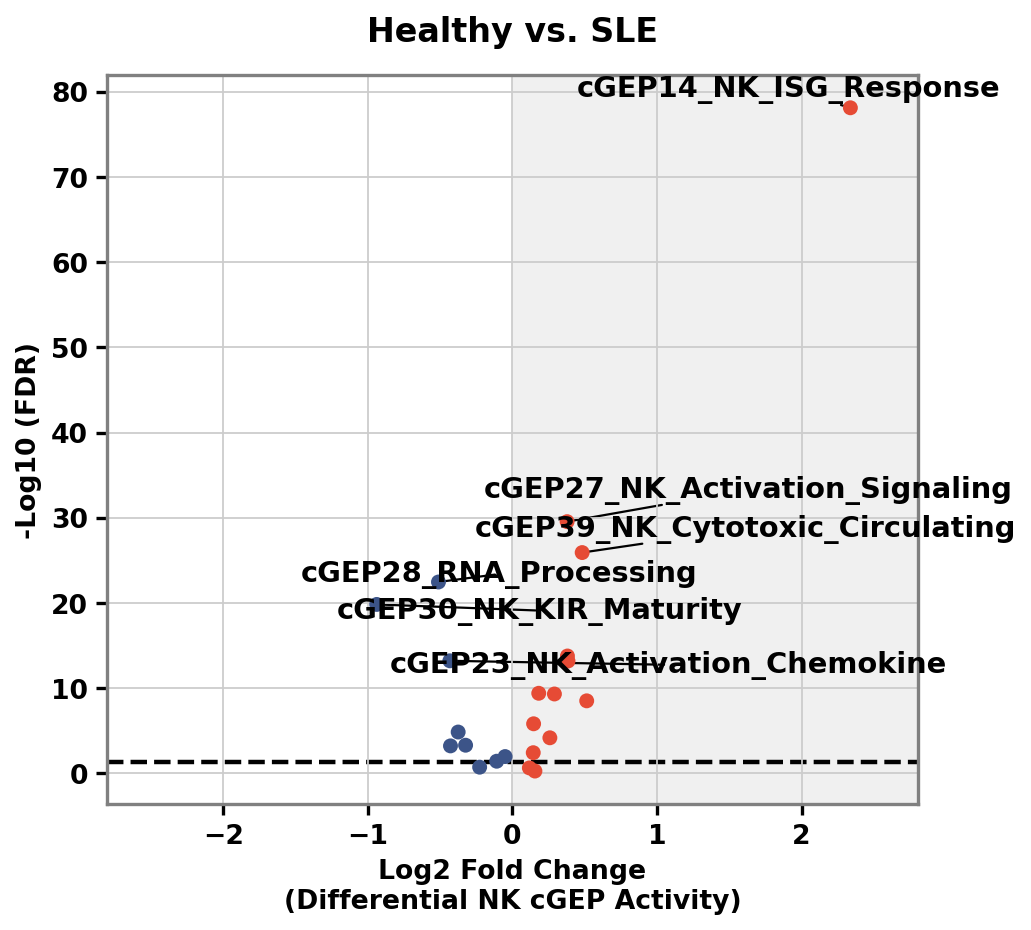

In [23]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from adjustText import adjust_text
except ImportError:
    pass

# ===========================
# 第一步：准备数据与差异分析
# ===========================

# 1. 提取所有 Usage 列
usage_cols = [c for c in query_adata.obs.columns if c.startswith('Usage:')]
gep_data = query_adata.obs[usage_cols]

# 2. 创建临时 AnnData 对象
gep_adata = sc.AnnData(X=gep_data.values, obs=query_adata.obs)
gep_adata.var_names = usage_cols

# 3. 运行差异分析 (Wilcoxon 秩和检验)
print("正在对比: SLE vs Healthy (HC)...")
sc.tl.rank_genes_groups(
    gep_adata, 
    groupby='group2_condition',  # 使用您刚才创建的分组
    groups=['SLE'],              # 实验组：SLE
    reference='Healthy',         # 对照组：Healthy
    method='wilcoxon'
)

# 4. 提取结果表
result = sc.get.rank_genes_groups_df(gep_adata, group='SLE')
df_volcano = result[['names', 'logfoldchanges', 'pvals_adj']].copy()
df_volcano.columns = ['GEP_Name', 'log2FC', 'padj']

# ===========================
# 第二步：数据清洗与提取最显著基因
# ===========================
pval_th = 0.05

# 去除无效值，并科学处理极小 P 值防止 -log10 报错
df_volcano = df_volcano.replace([np.inf, -np.inf], np.nan).dropna()
df_volcano['padj'] = df_volcano['padj'].clip(lower=1e-300) 
df_volcano['log_pval'] = -np.log10(df_volcano['padj'])

# 【新增逻辑】提取 P 值最显著的 Top 5 上调和下调 cGEP（用于打印和图表标注）
top_up = df_volcano[(df_volcano['log2FC'] > 0) & (df_volcano['padj'] < pval_th)].sort_values('padj').head(3)
top_dn = df_volcano[(df_volcano['log2FC'] < 0) & (df_volcano['padj'] < pval_th)].sort_values('padj').head(3)

# 合并，变量名为 top_genes
top_genes = pd.concat([top_up, top_dn])

print("\n分析完成。以下是将在火山图上标注的极显著 cGEP：")
print("\n--- 在 SLE 中最显著上调的 Top 5 cGEP (对应图右侧红点) ---")
print(top_up[['GEP_Name', 'log2FC', 'padj', 'log_pval']].to_string(index=False))

print("\n--- 在 SLE 中最显著下调的 Top 5 cGEP (对应图左侧蓝点) ---")
print(top_dn[['GEP_Name', 'log2FC', 'padj', 'log_pval']].to_string(index=False))

# ===========================
# 第三步：绘制高分文献风格火山图
# ===========================

# 1. 定义颜色 (仿照参考图，按正负着色：右侧红色，左侧蓝色)
df_volcano['color'] = np.where(df_volcano['log2FC'] > 0, '#E64B35', '#3C5488') 
df_volcano['alpha'] = 1.0

# 2. 开始绘图
fig, ax = plt.subplots(figsize=(6.5, 6)) # 采用接近正方形的比例

# 【关键特征】添加右侧灰色阴影背景
# 获取X轴最大值以确定阴影右边界
x_max = abs(df_volcano['log2FC']).max() * 1.2 
ax.axvspan(0, x_max, facecolor='#f0f0f0', zorder=0)

# 绘制散点
ax.scatter(
    df_volcano['log2FC'], 
    df_volcano['log_pval'], 
    c=df_volcano['color'], 
    s=45, 
    alpha=df_volcano['alpha'], 
    edgecolors='none', 
    zorder=2
)

# 【关键特征】只添加水平黑色粗虚线作为 Q-value/P-value 阈值
ax.axhline(y=-np.log10(pval_th), color='black', linestyle='--', linewidth=2, zorder=1)

# 3. 标注显著的点 (使用刚刚提取的 top_genes)
texts = []
for _, row in top_genes.iterrows():
    simple_name = row['GEP_Name'].replace('Usage: ', '')
    # 【全局加粗】添加字体加粗参数 fontweight='bold'
    texts.append(ax.text(row['log2FC'], row['log_pval'], simple_name, 
                         fontsize=13, fontweight='bold', zorder=3))

# 使用 adjust_text 自动避让
try:
    # 【关键特征】连线使用简单的黑色直线，不带箭头
    adjust_text(texts, 
                arrowprops=dict(arrowstyle='-', color='black', lw=1.0),
                ax=ax)
except NameError:
    print("提示: 未安装 adjustText，标签可能会重叠。")

# 4. 装饰图片与【全局加粗】
ax.set_title('Healthy vs. SLE', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Log2 Fold Change\n(Differential NK cGEP Activity)', fontsize=12, fontweight='bold') 
ax.set_ylabel('-Log10 (FDR)', fontsize=12, fontweight='bold')

# 加粗刻度文字
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# 加粗坐标轴边框
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#808080')
ax.tick_params(width=1.5, length=5) # 加粗刻度线本身

# 设置对称的 X 轴范围，使 0 刻度居中，视觉效果更好
ax.set_xlim(-x_max, x_max)

# ===========================
# 第四步：保存与展示
# ===========================
os.makedirs("./5.disease/5.2.SLE", exist_ok=True)
output_file = "./5.disease/5.2.SLE/5.2.NK_SLE_Volcano_SLETcell_Usage-v0420.pdf"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n图片已保存为: {output_file}")
plt.show()